In [ ]:
from google.colab import files

uploaded = files.upload()

Saving student_data.csv to student_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
filename = next(iter(uploaded))

df = pd.read_csv(filename)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.shape

(395, 33)

In [ ]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
school,0.0
sex,0.0
age,0.0
address,0.0
famsize,0.0
Pstatus,0.0
Medu,0.0
Fedu,0.0
Mjob,0.0
Fjob,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_cols)

Numerical Columns:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')


In [ ]:
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


In [ ]:
df[numeric_cols].describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 school
school
GP    349
MS     46
Name: count, dtype: int64

 sex
sex
F    208
M    187
Name: count, dtype: int64

 address
address
U    307
R     88
Name: count, dtype: int64

 famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64

 Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64

 Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

 Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

 reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

 guardian
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

 schoolsup
schoolsup
no     344
yes     51
Name: count, dtype: int64

 famsup
famsup
yes    242
no     153
Name: count, dtype: int64

 paid
paid
no     214
yes    181
Name: count, dtype: int64

 activities
activities
yes    201
no     194
Name: count, dty

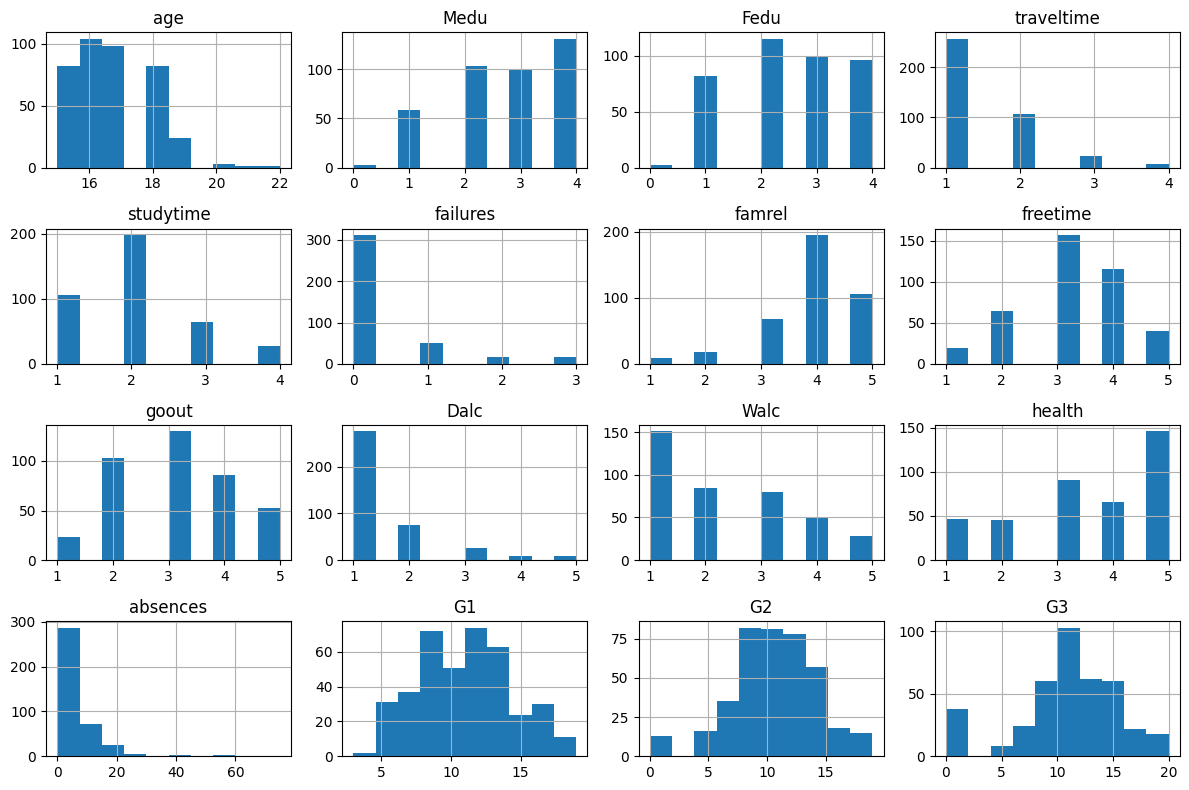

In [ ]:
df[numeric_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

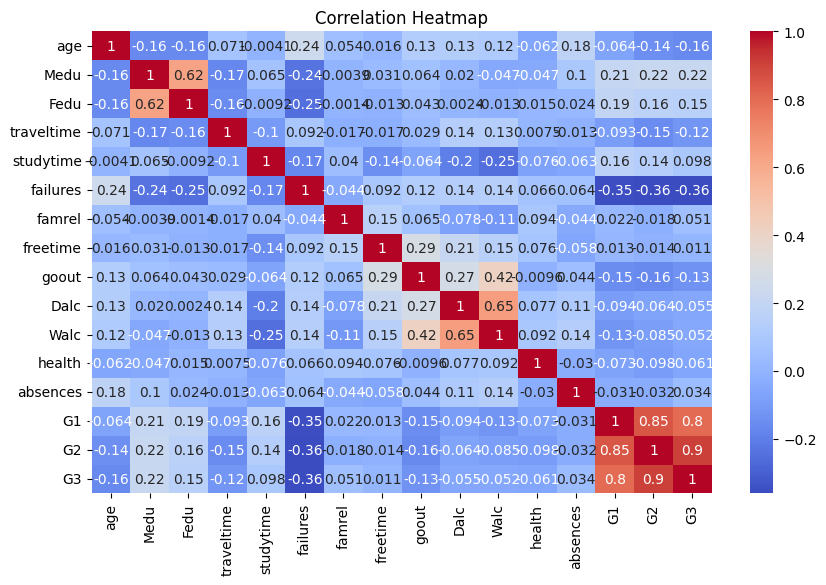

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

NameError: name 'X' is not defined

In [ ]:
# Features for clustering
X = df[
    [
        "G1",
        "G2",
        "studytime",
        "failures",
        "Average_Grade"
    ]
]

print("Features selected for clustering:")
print(X.columns)

print("\nShape:", X.shape)

KeyError: "['Average_Grade'] not in index"

In [ ]:
df["Average_Grade"] = (df["G1"] + df["G2"] + df["G3"]) / 3

In [ ]:
df[["G1", "G2", "G3", "Average_Grade"]].head()

,G1,G2,G3,Average_Grade
0,5,6,6,5.666667
1,5,5,6,5.333333
2,7,8,10,8.333333
3,15,14,15,14.666667
4,6,10,10,8.666667


In [ ]:
X = df[
    [
        "G1",
        "G2",
        "studytime",
        "failures",
        "Average_Grade"
    ]
]

In [ ]:
X.head()

,G1,G2,studytime,failures,Average_Grade
0,5,6,2,0,5.666667
1,5,5,2,0,5.333333
2,7,8,2,3,8.333333
3,15,14,3,0,14.666667
4,6,10,2,0,8.666667


In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
inertias = []

for k in range(2, 11):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KMeans(n_clusters=k, random_state=42, n_init=10))
    ])

    pipeline.fit(X)

    inertias.append(pipeline.named_steps["model"].inertia_)

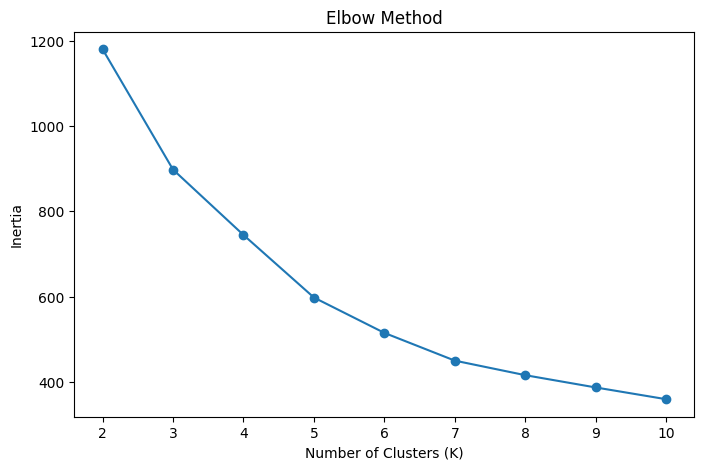

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    ))
])

kmeans_pipeline.fit(X)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['G1', 'G2', 'studytime', 'failures', 'Average_Grade'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model', KMeans(n_clusters=3, n_init=10, random_state=42))])

In [ ]:
df["KMeans_Cluster"] = kmeans_pipeline.predict(X)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,Average_Grade,KMeans_Cluster
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,5.666667,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,5.333333,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,8.333333,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,14.666667,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,8.666667,0


In [ ]:
X_transformed = kmeans_pipeline.named_steps["preprocessor"].transform(X)

In [ ]:
kmeans_labels = kmeans_pipeline.named_steps["model"].labels_

In [ ]:
kmeans_score = silhouette_score(
    X_transformed,
    kmeans_labels
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.3270724485139211


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Study_Hours"],
    df["Exam_Score"],
    c=df["KMeans_Cluster"]
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("K-Means Student Clusters")

plt.show()

KeyError: 'Study_Hours'

<Figure size 800x600 with 0 Axes>

In [ ]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Average_Grade', 'KMeans_Cluster']


In [ ]:
df["Study_Hours"]

KeyError: 'Study_Hours'

In [ ]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Average_Grade', 'KMeans_Cluster']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (395, 5)


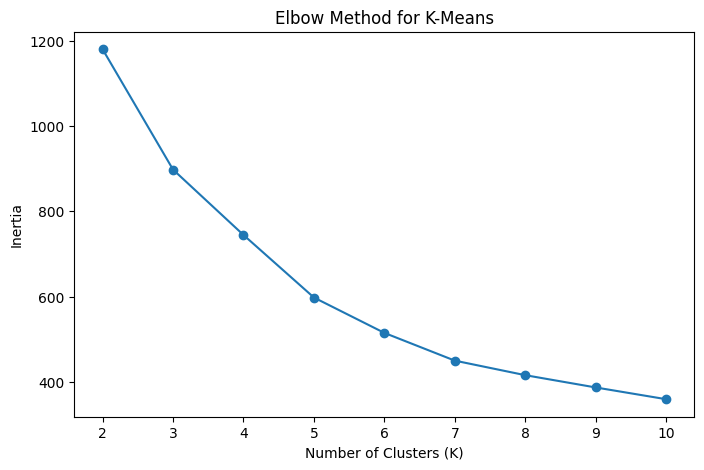

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print(df["KMeans_Cluster"].value_counts())

KMeans_Cluster
0    185
1    157
2     53
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.3270724485139211


In [ ]:
df.groupby("KMeans_Cluster")[
    ["G1", "G2", "studytime", "failures", "Average_Grade"]
].mean()

,G1,G2,studytime,failures,Average_Grade
KMeans_Cluster,,,,,
0,9.194595,9.097297,2.086486,0.102703,8.996396
1,14.261146,14.184713,2.133758,0.101911,14.269639
2,6.962264,6.075472,1.566038,1.830189,5.918239


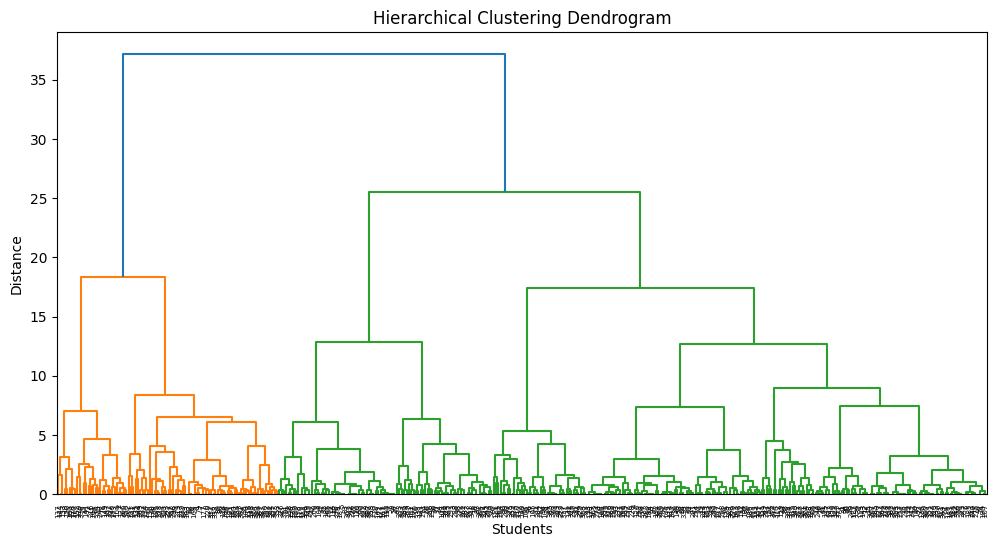

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

In [46]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

hierarchical_model = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_labels

print(df["Hierarchical_Cluster"].value_counts())

hierarchical_score = silhouette_score(X_scaled, hierarchical_labels)

print("Hierarchical Silhouette Score:", hierarchical_score)

Hierarchical_Cluster
1    210
0     94
2     91
Name: count, dtype: int64
Hierarchical Silhouette Score: 0.2774522854588973


In [47]:
df.groupby("Hierarchical_Cluster")[
    ["G1", "G2", "studytime", "failures", "Average_Grade"]
].mean()

,G1,G2,studytime,failures,Average_Grade
Hierarchical_Cluster,,,,,
0,7.212766,6.063830,1.691489,1.095745,6.010638
1,10.680952,10.823810,2.023810,0.133333,10.739683
2,15.252747,15.263736,2.417582,0.010989,15.362637


In [48]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print("Clusters formed:", np.unique(dbscan_labels))
print("\nCluster counts:")
print(df["DBSCAN_Cluster"].value_counts())

Clusters formed: [-1  0  1  2  3  4  5  6]

Cluster counts:
DBSCAN_Cluster
 0    148
-1    116
 2     64
 1     43
 5      8
 3      6
 4      5
 6      5
Name: count, dtype: int64


In [49]:
from sklearn.metrics import silhouette_score

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:
    dbscan_score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    dbscan_score = np.nan
    print("Not enough clusters for Silhouette Score.")

DBSCAN Silhouette Score: 0.1425328154510035


In [50]:
df.groupby("DBSCAN_Cluster")[
    ["G1", "G2", "studytime", "failures", "Average_Grade"]
].mean()

,G1,G2,studytime,failures,Average_Grade
DBSCAN_Cluster,,,,,
-1,9.500000,8.672414,2.284483,1.025862,8.491379
0,11.222973,11.270270,2.000000,0.000000,11.308559
1,12.465116,12.441860,3.000000,0.000000,12.519380
2,11.187500,11.437500,1.000000,0.000000,11.401042
3,10.666667,10.833333,4.000000,0.000000,10.777778
4,17.800000,18.400000,1.000000,0.000000,18.200000
5,13.250000,11.375000,2.000000,1.000000,12.083333
6,7.000000,8.600000,1.000000,1.000000,7.866667


In [51]:
# Compare all clustering algorithms

results = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score,
        dbscan_score
    ]
})

display(results)

,Algorithm,Silhouette Score
0,K-Means,0.327072
1,Hierarchical,0.277452
2,DBSCAN,0.142533


In [52]:
# Find the best clustering algorithm

best_model = results.loc[
    results["Silhouette Score"].idxmax()
]

print("Best Clustering Algorithm:", best_model["Algorithm"])
print("Best Silhouette Score:", best_model["Silhouette Score"])

Best Clustering Algorithm: K-Means
Best Silhouette Score: 0.3270724485139211
